![title](imagens/cabec_08c.jpg)

# <font color='green'>Projeto 2 - Escala e Normalização dos dados</font>
## <font color='green'>Instalando os Pacotes e Carregando os Dados</font>

## Instalando e Carregando os Pacotes

In [1]:
# Versão da Linguagem Python
from platform import python_version
print('Versão da Linguagem Python Usada Neste Jupyter Notebook:', python_version())

Versão da Linguagem Python Usada Neste Jupyter Notebook: 3.11.7


In [2]:
# Para atualizar um pacote, execute o comando abaixo no terminal ou prompt de comando:
# pip install -U nome_pacote

# Para instalar a versão exata de um pacote, execute o comando abaixo no terminal ou prompt de comando:
# !pip install nome_pacote==versão_desejada

# Depois de instalar ou atualizar o pacote, reinicie o jupyter notebook.

# Instala o pacote watermark. 
# Esse pacote é usado para gravar as versões de outros pacotes usados neste jupyter notebook.
#!pip install -q -U watermark
#!conda install -c conda-forge mlxtend
!pip install -q -U mlxtend

In [3]:
# Importação dos módulos básicos
import numpy as np
import pandas as pd
# Importação para transformação Box-Cox
from scipy import stats
# para fazer a escala de min-max
import mlxtend
from mlxtend.preprocessing import minmax_scaling
# módulos para fazer os gráficos (plotagens)
import seaborn as sns
import matplotlib.pyplot as plt
# módulo para ignorar mensagens de alerta
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Versões dos pacotes usados neste jupyter notebook
# %reload_ext watermark
# %watermark -a "pyPRO - Seja um Profissional Python!" --iversions

Author: pyPRO - Seja um Profissional Python!

mlxtend   : 0.23.1
scipy     : 1.12.0
numpy     : 1.26.4
pandas    : 2.2.2
seaborn   : 0.13.2
matplotlib: 3.8.4



## Carregando os Dados

### Dataset publico: Kickstarter Projects  (mais de 300.000 projetos kickstarter)
Disponível em: https://www.kaggle.com/code/rtatman/data-cleaning-challenge-scale-and-normalize-data/input?select=ks-projects-201801.csv

Kickstarter é um site onde as pessoas podem pedir às pessoas que invistam em vários projetos e produtos conceituais.

Este arquivo estará disponível como recurso dessa aula.

In [5]:
# Criamos uma lista para identificar valores ausentes
lista_labels_valores_ausentes = ["n/a", "na", "undefined"]

In [6]:
# Carrega o dataset "Kickstarter Projets"
dataset = pd.read_csv("dados/ks-projects-201801.csv", na_values = lista_labels_valores_ausentes)

In [7]:
print(dataset.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 378661 entries, 0 to 378660
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   ID                378661 non-null  int64  
 1   name              378657 non-null  object 
 2   category          378661 non-null  object 
 3   main_category     378661 non-null  object 
 4   currency          378661 non-null  object 
 5   deadline          378661 non-null  object 
 6   goal              378661 non-null  float64
 7   launched          378661 non-null  object 
 8   pledged           378661 non-null  float64
 9   state             375099 non-null  object 
 10  backers           378661 non-null  int64  
 11  country           378661 non-null  object 
 12  usd pledged       374864 non-null  float64
 13  usd_pledged_real  378661 non-null  float64
 14  usd_goal_real     378661 non-null  float64
dtypes: float64(5), int64(2), object(8)
memory usage: 43.3+ MB


Vamos dar uma olhada nos dados. Nós já fizemos várias vezes com o método head(). Vamos utilizar o método sample, para variar.
Com ele, temos que informar a quantidade de amostra que queremos.

In [8]:
dataset.sample(6)

,ID,name,category,main_category,currency,deadline,goal,launched,pledged,state,backers,country,usd pledged,usd_pledged_real,usd_goal_real
240636,293866052,"Lot44 Album - ""Do What I Want""",Rock,Music,USD,2012-07-11,6000.0,2012-06-11 20:04:17,8306.0,successful,115,US,8306.00,8306.00,6000.00
139497,1708577673,MAGNIFICA,Product Design,Design,AUD,2016-10-17,8000.0,2016-09-17 03:51:09,2762.0,failed,51,AU,1586.97,2107.27,6103.61
83679,1425532432,Frances Grubb (and the Clever Title) (Canceled),Young Adult,Publishing,USD,2014-10-15,10850.0,2014-09-15 07:19:22,31.0,canceled,2,US,31.00,31.00,10850.00
250271,34298068,Workloadmeter,Technology,Technology,EUR,2016-09-23,3500.0,2016-07-25 22:59:30,15.0,failed,2,BE,5.49,16.82,3924.91
368662,948270170,"Spring Sounds, Spring Seas",Classical Music,Music,USD,2011-12-10,18000.0,2011-10-11 02:35:52,5525.0,failed,53,US,5525.00,5525.00,18000.00
200502,2020982056,Steven Ybarra New Full-Length CD and Music Video!,Music,Music,USD,2014-07-25,40000.0,2014-06-25 20:47:35,41575.0,successful,157,US,41575.00,41575.00,40000.00


In [9]:
dataset.shape

(378661, 15)

In [10]:
contagem_valores_ausentes = dataset.isnull().sum()
contagem_valores_ausentes[0:20]

ID                     0
name                   4
category               0
main_category          0
currency               0
deadline               0
goal                   0
launched               0
pledged                0
state               3562
backers                0
country                0
usd pledged         3797
usd_pledged_real       0
usd_goal_real          0
dtype: int64

In [11]:
# Calculando os totais de celulas e de celulas com valores ausentes (total_nulos)
total_celulas = np.prod(dataset.shape)
total_nulos = contagem_valores_ausentes.sum()
# Calculando o percentual de dados ausentes
print(f"Percentual de Dados ausentes: {(total_nulos/total_celulas):.2%}")

Percentual de Dados ausentes: 0.13%


## Escala (ou Dimensionamento) e Normalização

Uma das razões pelas quais é fácil confundir escala (ou dimensionamento) e normalização é porque os termos às vezes são usados de forma intercambiável e, para tornar ainda mais confuso, eles são muito semelhantes! 

Em ambos os casos, você está transformando os valores de variáveis numéricas para que os pontos de dados transformados tenham propriedades úteis específicas. 

A diferença é que, na escala (ou dimensionamento), você altera o intervalo de seus dados, enquanto na normalização, altera a forma da distribuição de seus dados. 

### Escala (ou Dimensionamento) 
Dimensionar ou mudar a escala, significa que você está transformando seus dados para que caibam em uma escala específica, como 0-100 ou 0-1. Você vai precisar dimensionar os dados quando estiver usando métodos baseados em medidas de pontos de dados distantes, como máquinas de vetor de suporte (SVM) ou k vizinhos mais próximos (KNN). Com esses algoritmos, uma alteração de "1" em qualquer recurso numérico recebe a mesma importância.

Por exemplo, você pode estar olhando os preços de alguns produtos em ienes e dólares americanos. Um dólar americano vale cerca de 100 ienes, mas se você não dimensionar seus preços, métodos como SVM ou KNN considerarão uma diferença de preço de 1 iene tão importante quanto uma diferença de 1 dólar americano! Isso claramente não se encaixa em nossas intuições do mundo. Com moeda, você pode converter entre moedas. Mas e se você estiver olhando para algo como altura e peso? Não está totalmente claro quantas libras devem ser iguais a uma polegada (ou quantos quilogramas devem ser iguais a um metro).

Ao dimensionar suas variáveis, você pode ajudar a comparar diferentes variáveis em pé de igualdade. 
Para ajudar a solidificar a aparência do dimensionamento (escala), vamos trabalhar com alguns dados fictícios (utilizando dados randomizados).

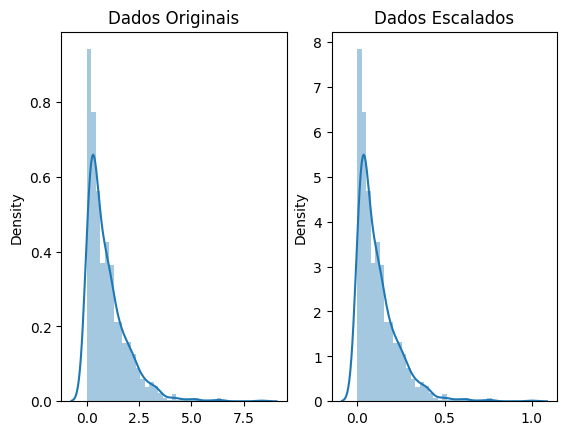

In [12]:
# Geração de 1000 pontos de dados randomicamente utilizando uma distribuição exponencial
dados_originais = np.random.exponential(size = 1000)

# dimensionando os dados min-max entre 0 e 1
dados_escalados = minmax_scaling(dados_originais, columns = [0])

# Fazendo os gráficos de ambos para comparação  (USANDO DISPLOT)
fig, ax=plt.subplots(1,2)
sns.distplot(dados_originais, ax=ax[0])
ax[0].set_title("Dados Originais")
sns.distplot(dados_escalados, ax=ax[1])
ax[1].set_title("Dados Escalados")
plt.show()

Observe que a forma dos dados não muda, mas em vez de variar de 0 a 8, agora varia de 0 a 1.

### Normalização
O dimensionamento (ou escala) apenas altera o intervalo de seus dados. 

A normalização é uma *transformação mais radical*. O objetivo da normalização é mudar suas observações para que possam ser descritas como uma **distribuição normal**.

**Distribuição normal**: também conhecida como "curva de sino", esta é uma distribuição estatística específica em que observações aproximadamente iguais ficam acima e abaixo da média, a média e a mediana são as mesmas e há mais observações mais próximas da média. A distribuição normal também é conhecida como *distribuição Gaussiana*.

Em geral, **você só deseja normalizar seus dados se for usar uma técnica de aprendizado de máquina ou estatística que suponha que seus dados sejam normalmente distribuídos**. Alguns exemplos disso incluem testes T, regressão linear, análise discriminante linear (LDA) e Naive Bayes Gaussiano. 

(Dica profissional: qualquer método com "Gaussian" no nome provavelmente assume normalidade.)

O método que estamos usando para normalizar aqui é chamado de *Transformação Box-Cox*. Vamos dar uma olhada rápida em como é a normalização de alguns dados:

In [13]:
# Normalizando os dados exponenciais com boxcox
dados_normalizados = stats.boxcox(dados_originais)[0]

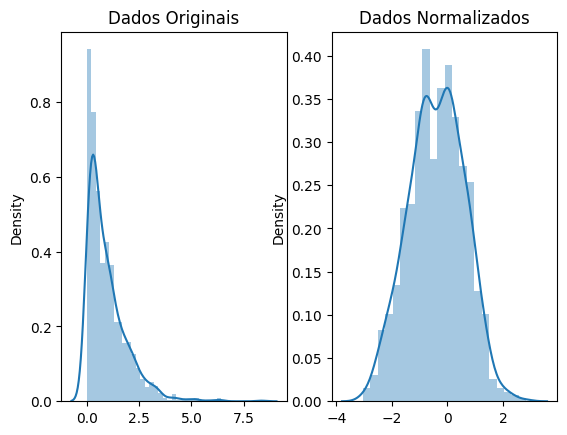

In [14]:
# Fazendo os gráficos de ambos para comparação  (USANDO DISTPLOT)
fig, ax=plt.subplots(1,2)
sns.distplot(dados_originais, ax=ax[0])
ax[0].set_title("Dados Originais")
sns.distplot(dados_normalizados, ax=ax[1])
ax[1].set_title("Dados Normalizados")
plt.show()

Vamos retornar ao Dataset do Kickstarter...

## Fazendo o Dimensionamento dos dados
Para ver na prática a aplicação das técnicas de dimensionamento (ou escala) e a normalização, usaremos um conjunto de dados de campanhas do Kickstarter. 

O Kickstarter é uma comunidade de mais de 10 milhões de pessoas, composta por entusiastas criativos e tecnológicos que ajudam a dar vida a projetos criativos. Mais de $ 3 bilhões de dólares foram contribuídos pelos membros para alimentar projetos criativos. 

Os projetos podem ser literalmente qualquer coisa - um dispositivo, um jogo, um aplicativo, um filme etc. O Kickstarter funciona com base no tudo ou nada, ou seja, se um projeto não atingir seu objetivo, o proprietário do projeto não recebe nada. Por exemplo, se a meta de um projeto for $ 500, mesmo que seja financiado até $ 499, o projeto não será um sucesso. 

Neste conjunto de dados, você transformará os valores de variáveis numéricas para que os pontos de dados transformados tenham propriedades úteis específicas.

Essas técnicas de transformação são conhecidas como dimensionamento ou escalonamento e normalização e uma diferença entre essas duas técnicas é que, no escalonamento, você está alterando o intervalo de seus dados enquanto na normalização está alterando a forma da distribuição de seus dados. 

Para entender o resultado de ambas as técnicas, também precisaremos de visualização, portanto, também usaremos algumas bibliotecas de visualização. Vamos entender cada um deles um por um.

Para dimensionar, primeiro você precisará instalar a biblioteca mlxtend, que é uma biblioteca Python de ferramentas úteis para as tarefas diárias de ciência de dados. Para esta instalação, utilize o comando: *conda install -c conda-forge mlxtend*

Já fizemos a importação do dataset, agora vamos começar realizando o dimensionamento dos objetivos de cada campanha (quanto dinheiro eles estavam pedindo)....

In [15]:
# Selecionando a coluna usd_goal_real (objetivo real em Dolar americano)
usd_goal = np.array(dataset.usd_goal_real)

# Dimensionando os objetivos entre 0 to 1
dados_escalados = minmax_scaling(usd_goal, columns = [0])

Text(0.5, 1.0, 'Dados Escalados')

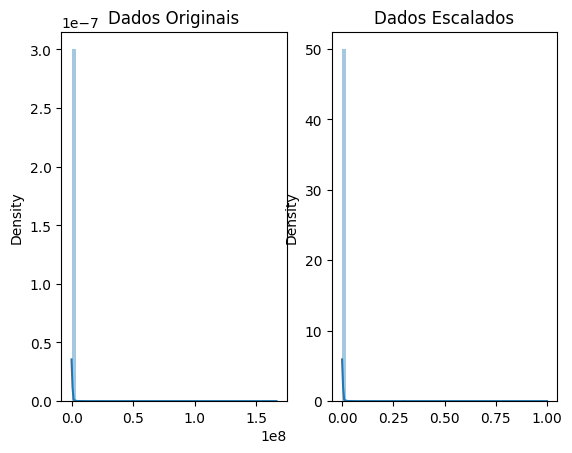

In [16]:
# Mostrando os gráficos dos dados Originais e os dimensinados para comparação (USANDO DISTPLOT)
fig, ax=plt.subplots(1,2)
sns.distplot(usd_goal, ax=ax[0])
ax[0].set_title("Dados Originais")
sns.distplot(dados_escalados, ax=ax[1])
ax[1].set_title("Dados Escalados")

Você pode ver que o dimensionamento mudou drasticamente as escalas dos gráficos (mas não a forma dos dados: parece que a maioria das campanhas tem metas pequenas, mas algumas têm metas muito grandes)

## Fazendo a Normalização dos dados
Vamos normalizar a quantia de dinheiro prometida (pledged) para cada campanha.

Você pode ver que o dimensionamento mudou drasticamente as escalas dos gráficos (mas não a forma dos dados: parece que a maioria das campanhas tem metas pequenas, mas algumas têm metas muito grandes)

Text(0.5, 1.0, 'Dados Normalizados')

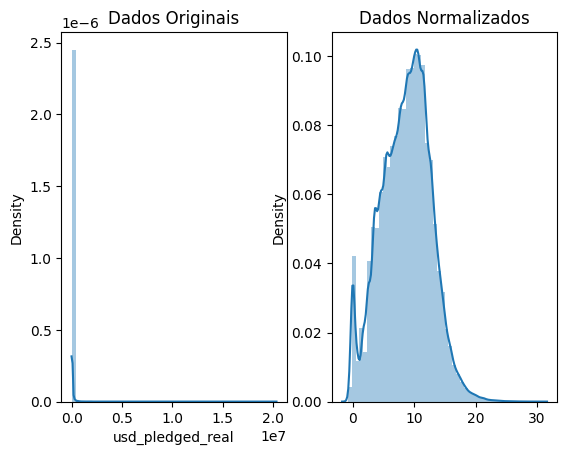

In [17]:
# Obtendo o índice de todos os get the index of all positive pledges (Box-Cox only takes postive values)
indice_retorno_positivo = dataset.usd_pledged_real > 0

# Obtendo apenas os retornos positivos (usando seus índices)
retornos_positivos = dataset.usd_pledged_real.loc[indice_retorno_positivo]

# Normalizando os Retornos (c/ Box-Cox)
retornos_normalizados = stats.boxcox(retornos_positivos)[0]

# Fazendo os gráficos comparativos de ambos
fig, ax=plt.subplots(1,2)
sns.distplot(retornos_positivos, ax=ax[0])
ax[0].set_title("Dados Originais")
sns.distplot(retornos_normalizados, ax=ax[1])
ax[1].set_title("Dados Normalizados")

Ainda não parece perfeito... todavia agora conseguimos verificar que muitas promessas foram pouco estimadas (estimativas baixas). E algumas, muito altas.
Com o processo de normalização os dados refletem algo mais próximo do normal! 


# Fim Projeto 2